# Step 5: Inventory Preparation and Factor Stack Assembly

This notebook prepares the landslide inventory and assembles the conditioning-factor stack for landslide susceptibility mapping.

It supports two modes:

1. Download and use the USGS Gnyawali inventory
Gnyawali, K.R., Adhikari, B.R.: Earthquake induced landslides triggered by 2015 Gorkha earthquake Mw 7.8, https://doi.org/10.5066/F7028Q2X, 2017, in Schmitt, R., Tanyas, H., Jessee, M.A., Zhu, J., Biegel, K., Allstadt, K.E., Jibson, R.W., Thompson, E.M., van Westen, C., Sato, H.P., Wald, D.J., Godt, J.W., Gorum, T., Moss, R.E.S., Xu, C, Rathje, E.M., Knudsen, K.L., 2017, An Open Repository of Earthquake-triggered Ground Failure Inventories, U.S. Geological Survey data release collection, https://doi.org/10.5066/F7H70DB4.
2. Use a user-supplied inventory

The workflow is raster-based and creates sampled training points from:
- landslide pixels
- non-landslide pixels

Balanced sampling is used by default.

## Configuration

The following keys should be defined in Step 1 (`watershed_analysis.json`):

- `use_example_inventory`
- `example_inventory_url`
- `landslide_inventory_path`
- `inventory_layer`
- `inventory_is_polygon`
- `sampling_mode`
- `max_positive_samples`
- `negative_to_positive_ratio`
- `random_seed`
- `use_manual_thematic_factors`
- `manual_thematic_factors`

If `use_example_inventory` is `true`, this notebook will download the USGS Gnyawali inventory automatically.
If `use_example_inventory` is `false`, the notebook will use `landslide_inventory_path`.

In [56]:
import json
import os
import warnings
 
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio import features
from rasterio.enums import Resampling
from rasterio.warp import reproject
from shapely.geometry import Point
 
warnings.filterwarnings("ignore")
 
with open("watershed_analysis.json", "r") as f:
    config = json.load(f)
 
# FIX: point_id must match Step 3/4
point_id = 1
 
factor_output_dir  = config.get("factor_output_dir",  os.path.join(config["output_dir"], "factors"))
landform_output_dir = config.get("landform_output_dir", os.path.join(config["output_dir"], "landforms"))
 
config.setdefault("inventory_output_dir",        os.path.join(config["output_dir"], "inventory_prepared"))
config.setdefault("stack_output_dir",            os.path.join(config["output_dir"], "lsm_stack"))
config.setdefault("use_example_inventory",       False)
config.setdefault("example_inventory_path",      "")
config.setdefault("landslide_inventory_path",    "")
config.setdefault("inventory_layer",             None)
config.setdefault("inventory_is_polygon",        True)
config.setdefault("sampling_mode",               "balanced")
config.setdefault("max_positive_samples",        None)
config.setdefault("negative_to_positive_ratio",  1.0)
config.setdefault("random_seed",                 42)
config.setdefault("manual_thematic_factors",     {})
config.setdefault("use_manual_thematic_factors", False)
 
os.makedirs(config["inventory_output_dir"], exist_ok=True)
os.makedirs(config["stack_output_dir"], exist_ok=True)
 
np.random.seed(config["random_seed"])
 
print("Configuration loaded")
print(f"point_id                : {point_id}")
print(f"Factor directory        : {factor_output_dir}")
print(f"Landform directory      : {landform_output_dir}")
print(f"Inventory output dir    : {config['inventory_output_dir']}")
print(f"Stack output dir        : {config['stack_output_dir']}")
print(f"Use example inventory   : {config['use_example_inventory']}")
print(f"Use manual thematic     : {config['use_manual_thematic_factors']}")

Configuration loaded
point_id                : 1
Factor directory        : results/factors
Landform directory      : results/landforms
Inventory output dir    : results/inventory_prepared
Stack output dir        : results/lsm_stack
Use example inventory   : False
Use manual thematic     : False


In [57]:
point_id = 1
factor_output_dir = config.get("factor_output_dir", os.path.join(config["output_dir"], "factors"))
landform_output_dir = config.get("landform_output_dir", os.path.join(config["output_dir"], "landforms"))

In [58]:
# ── Helpers ────────────────────────────────────────────────────────────────────
 
def find_first_existing(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None
 
 
import os
import requests
import zipfile
 
import os, requests, zipfile

import os
import requests
import zipfile

import os
import requests
import zipfile

def download_usgs_inventory(dest_dir):
    os.makedirs(dest_dir, exist_ok=True)
    extract_dir = os.path.join(dest_dir, "Gnyawali_and_others_2016")

    # Check if already extracted
    if not os.path.exists(extract_dir):
        # Look for a manually placed ZIP
        zip_path = os.path.join(dest_dir, "Gnyawali_and_others_2016.zip")
        if not os.path.exists(zip_path):
            raise FileNotFoundError(
                "Please manually download the data from:\n"
                "https://www.sciencebase.gov/catalog/item/5874a7cee4b0a829a320bb3e\n"
                f"and place the ZIP at: {zip_path}"
            )
        print("Extracting inventory...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_dir)

    for root, _, files in os.walk(extract_dir):
        for file in files:
            if file.lower().endswith(".shp"):
                return os.path.join(root, file)

    raise FileNotFoundError("No shapefile found after extraction.")
    
def load_reference_raster():
    # FIX: all Step 3 outputs have _{point_id} suffix
    candidates = [
        os.path.join(factor_output_dir, f"elevation_{point_id}.tif"),
        os.path.join(factor_output_dir, f"watershed_dem_{point_id}_projected.tif"),
        os.path.join(config["output_dir"], f"watershed_dem_{point_id}.tif"),
    ]
    ref = find_first_existing(candidates)
    if not ref:
        raise FileNotFoundError(f"Could not find a reference raster. Searched:\n" + "\n".join(candidates))
    return ref
 
 
def load_watershed_boundary():
    # FIX: Step 2 saves watershed_{point_id}.shp
    candidates = [
        os.path.join(config["output_dir"], f"watershed_{point_id}.shp"),
        os.path.join(config["output_dir"], "watershed.shp"),
        os.path.join(config["output_dir"], "watersheds.shp"),
    ]
    shp = find_first_existing(candidates)
    if not shp:
        raise FileNotFoundError(f"Could not find watershed boundary. Searched:\n" + "\n".join(candidates))
    return gpd.read_file(shp)
 
 
def aligned_read(src_path, ref_profile):
    with rasterio.open(src_path) as src:
        dst = np.full((ref_profile["height"], ref_profile["width"]), np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=dst,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src.nodata,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            dst_nodata=np.nan,
            resampling=Resampling.bilinear,
        )
    return dst
 
 
def aligned_read(path, ref_profile, nearest=False):
    resampling = Resampling.nearest if nearest else Resampling.bilinear
    with rasterio.open(path) as src:
        if (src.crs == ref_profile["crs"] and
            src.transform == ref_profile["transform"] and
            src.width == ref_profile["width"] and
            src.height == ref_profile["height"]):
            return src.read(1).astype(np.float32)
        
        data = np.empty((ref_profile["height"], ref_profile["width"]), dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            resampling=resampling,
        )
        return data
 

def expected_factor_path(factor_name, point_id):
    path = os.path.join(factor_output_dir, f"{factor_name}_{point_id}.tif")
    return path if os.path.exists(path) else None

def expected_landform_path(point_id):
    path = os.path.join(factor_output_dir, f"landform_{point_id}.tif")
    return path if os.path.exists(path) else None


def write_raster(path, array, profile, dtype="float32", nodata=None):
    out_profile = profile.copy()
    out_profile.update(count=1, dtype=dtype)
    if nodata is not None and not (isinstance(nodata, float) and np.isnan(nodata)):
        out_profile["nodata"] = nodata
    else:
        out_profile.pop("nodata", None)
    
    with rasterio.open(path, "w", **out_profile) as dst:
        dst.write(array.astype(dtype), 1)
 
def rc_to_xy(row, col, transform):
    x, y = rasterio.transform.xy(transform, row, col, offset="center")
    return x, y
 
 
def choose_inventory_path(config):
    """
    Resolve the landslide inventory path according to config settings.
 
    Priority:
    1. If ``use_example_inventory`` is True and ``example_inventory_path``
       points to an existing file, use it directly.
    2. If ``landslide_inventory_path`` is set and the file exists, use it.
    3. Otherwise, download the USGS ScienceBase inventory automatically and
       use the first shapefile found in the extracted archive.
 
    Returns
    -------
    (path, mode) : tuple[str, str]
        path  – absolute path to the inventory shapefile / GeoPackage
        mode  – one of "example", "user_supplied", or "usgs_download"
    """
    # 1. Explicitly requested example inventory
    example_path = config.get("example_inventory_path", "")
    if config.get("use_example_inventory", False):
        if example_path and os.path.exists(example_path):
            return os.path.abspath(example_path), "example"
        raise FileNotFoundError(
            f"use_example_inventory is True but example_inventory_path does not exist: {example_path!r}"
        )
 
    # 2. User-supplied inventory
    user_path = config.get("landslide_inventory_path", "")
    if user_path and os.path.exists(user_path):
        return os.path.abspath(user_path), "user_supplied"
 
    # 3. Auto-download USGS inventory
    print("No local inventory found — downloading USGS ScienceBase inventory...")
    dest_dir = os.path.join(config.get("output_dir", "."), "inventory_raw")
    shp_path = download_usgs_inventory(dest_dir)
    return shp_path, "usgs_download"

In [59]:
# ── Load reference data ────────────────────────────────────────────────────────
 
reference_raster = load_reference_raster()
watershed_gdf    = load_watershed_boundary()
inventory_path, inventory_mode = choose_inventory_path(config)
 
with rasterio.open(reference_raster) as ref:
    ref_profile   = ref.profile.copy()
    ref_transform = ref.transform
    ref_crs       = ref.crs
    ref_shape     = (ref.height, ref.width)
    ref_bounds    = ref.bounds
 
watershed_gdf = watershed_gdf.to_crs(ref_crs)
 
print(f"\nReference raster : {reference_raster}")
print(f"Inventory path   : {inventory_path}")
print(f"Inventory mode   : {inventory_mode}")
print(f"Reference CRS    : {ref_crs}")

No local inventory found — downloading USGS ScienceBase inventory...

Reference raster : results/factors/elevation_1.tif
Inventory path   : results/inventory_raw/Gnyawali_and_others_2016/Gnyawali_others_2016_poly.shp
Inventory mode   : usgs_download
Reference CRS    : EPSG:32645


## Load and clip landslide inventory

In [60]:
inventory_gdf = gpd.read_file(inventory_path, layer=config["inventory_layer"])
inventory_gdf = inventory_gdf.to_crs(ref_crs)

# Fix invalid geometries
inventory_gdf["geometry"] = inventory_gdf.geometry.buffer(0)
watershed_gdf["geometry"] = watershed_gdf.geometry.buffer(0)
inventory_gdf = inventory_gdf[inventory_gdf.geometry.is_valid]
watershed_gdf = watershed_gdf[watershed_gdf.geometry.is_valid]

# Clip to watershed
inventory_clipped = gpd.clip(inventory_gdf, watershed_gdf)

if inventory_clipped.empty:
    raise ValueError("Clipped landslide inventory is empty.")

clipped_inventory_path = os.path.join(
    config["inventory_output_dir"], f"landslide_inventory_clipped_{point_id}.gpkg"
)
inventory_clipped.to_file(clipped_inventory_path, driver="GPKG")
print(f"Inventory features after clipping: {len(inventory_clipped)}")
print(f"Saved clipped inventory: {clipped_inventory_path}")

Inventory features after clipping: 2330
Saved clipped inventory: results/inventory_prepared/landslide_inventory_clipped_1.gpkg


In [61]:
landslide_mask = features.rasterize(
    [(geom, 1) for geom in inventory_clipped.geometry if geom is not None and not geom.is_empty],
    out_shape=ref_shape,
    transform=ref_transform,
    fill=0,
    dtype="uint8"
)

landslide_mask_path = os.path.join(config["inventory_output_dir"], f"landslide_mask_{point_id}.tif")
write_raster(landslide_mask_path, landslide_mask, ref_profile, dtype="uint8", nodata=0)

print(f"Saved landslide mask: {landslide_mask_path}")
print(f"Landslide pixels: {int((landslide_mask == 1).sum())}")

Saved landslide mask: results/inventory_prepared/landslide_mask_1.tif
Landslide pixels: 8342


## Load factor rasters

In [62]:
factor_candidates = {
    "elevation": expected_factor_path("elevation", point_id),
    "slope": expected_factor_path("slope_deg", point_id) or expected_factor_path("slope", point_id),
    "aspect": expected_factor_path("aspect_deg", point_id) or expected_factor_path("aspect", point_id),
    "plan_curvature": expected_factor_path("plan_curvature", point_id),
    "profile_curvature": expected_factor_path("profile_curvature", point_id),
    "flow_accumulation": expected_factor_path("flow_accumulation", point_id),
    "twi": expected_factor_path("topographic_wetness_index", point_id) or expected_factor_path("twi", point_id),
    "tri": expected_factor_path("terrain_ruggedness_index", point_id) or expected_factor_path("tri", point_id),
    "tpi": expected_factor_path("topographic_position_index", point_id) or expected_factor_path("tpi", point_id),
    "roughness": expected_factor_path("surface_roughness", point_id) or expected_factor_path("roughness", point_id),
    "distance_to_streams": expected_factor_path("distance_to_streams", point_id),
    "spi": expected_factor_path("stream_power_index", point_id) or expected_factor_path("spi", point_id),
    "landform": expected_landform_path(point_id),
}

factor_arrays = {}
factor_registry = {}

for name, path in factor_candidates.items():
    if path and os.path.exists(path):
        factor_arrays[name] = aligned_read(path, ref_profile, nearest=(name == "landform"))
        factor_registry[name] = path

if config.get("use_manual_thematic_factors", False):
    for name, path in config.get("manual_thematic_factors", {}).items():
        if path and os.path.exists(path):
            factor_arrays[name] = aligned_read(path, ref_profile, nearest=True)
            factor_registry[name] = path

if not factor_arrays:
    raise ValueError("No factor rasters found.")

print("Loaded factors:")
for name in sorted(factor_arrays):
    print("-", name)

Loaded factors:
- aspect
- distance_to_streams
- elevation
- flow_accumulation
- plan_curvature
- profile_curvature
- roughness
- slope
- spi
- tpi
- tri
- twi


## Build valid analysis mask

In [63]:
valid_mask = np.ones(ref_shape, dtype=bool)

for _, arr in factor_arrays.items():
    valid_mask &= np.isfinite(arr)

valid_mask_path = os.path.join(config["stack_output_dir"], f"valid_analysis_mask_{point_id}.tif")
write_raster(valid_mask_path, valid_mask.astype("uint8"), ref_profile, dtype="uint8", nodata=0)

print(f"Valid pixels: {int(valid_mask.sum())}")
print(f"Saved valid mask: {valid_mask_path}")

Valid pixels: 950102
Saved valid mask: results/lsm_stack/valid_analysis_mask_1.tif


## Sample balanced training points

In [64]:
positive_rc = np.argwhere((landslide_mask == 1) & valid_mask)
negative_rc = np.argwhere((landslide_mask == 0) & valid_mask)

if len(positive_rc) == 0:
    raise ValueError("No positive landslide pixels found after clipping and masking.")
if len(negative_rc) == 0:
    raise ValueError("No negative pixels available for sampling.")

max_pos = config["max_positive_samples"]
n_pos = min(len(positive_rc), int(max_pos)) if max_pos is not None else len(positive_rc)

if config["sampling_mode"] == "balanced":
    n_neg = min(len(negative_rc), n_pos)
else:
    n_neg = min(len(negative_rc), int(n_pos * float(config["negative_to_positive_ratio"])))

pos_idx = np.random.choice(len(positive_rc), size=n_pos, replace=False)
neg_idx = np.random.choice(len(negative_rc), size=n_neg, replace=False)

sampled_pos = positive_rc[pos_idx]
sampled_neg = negative_rc[neg_idx]

print(f"Positive samples: {len(sampled_pos)}")
print(f"Negative samples: {len(sampled_neg)}")

Positive samples: 8342
Negative samples: 8342


In [65]:
records = []

def rc_to_xy(row, col, transform):
    x, y = rasterio.transform.xy(transform, row, col, offset="center")
    return x, y

for rc_set, label in [(sampled_pos, 1), (sampled_neg, 0)]:
    for row, col in rc_set:
        x, y = rc_to_xy(row, col, ref_transform)
        record = {
            "point_id": int(point_id),
            "row": int(row),
            "col": int(col),
            "x": float(x),
            "y": float(y),
            "label": int(label),
        }
        for factor_name, arr in factor_arrays.items():
            record[factor_name] = float(arr[row, col])
        records.append(record)

training_df = pd.DataFrame(records)
training_points_gdf = gpd.GeoDataFrame(
    training_df.copy(),
    geometry=[Point(xy) for xy in zip(training_df["x"], training_df["y"])],
    crs=ref_crs
)

training_csv = os.path.join(config["stack_output_dir"], f"lsm_training_samples_{point_id}.csv")
training_gpkg = os.path.join(config["stack_output_dir"], f"lsm_training_samples_{point_id}.gpkg")

training_df.to_csv(training_csv, index=False)
training_points_gdf.to_file(training_gpkg, driver="GPKG")

print(f"Saved training table: {training_csv}")
print(f"Saved training points: {training_gpkg}")
training_df.head()

Saved training table: results/lsm_stack/lsm_training_samples_1.csv
Saved training points: results/lsm_stack/lsm_training_samples_1.gpkg


,point_id,row,col,x,y,label,elevation,slope,aspect,plan_curvature,profile_curvature,flow_accumulation,twi,tri,tpi,roughness,distance_to_streams,spi
0,1,758,621,364840.654324,3.094472e+06,1,1792.602173,47.635075,0.786020,-0.003796,-0.000874,8.779799,5.815921,26.126179,-3.792304,89.452271,3425.686035,2.461589
1,1,609,297,355269.513066,3.098873e+06,1,2138.785400,42.806438,1.612246,-0.005068,0.000559,0.000000,7.227346,22.269157,-1.679226,66.211426,11596.503906,0.655559
2,1,553,421,358932.542436,3.100527e+06,1,3312.320557,39.992245,3.958314,0.002069,-0.002808,6.001162,5.588130,20.576090,-2.355523,70.893799,7582.262207,1.927609
3,1,390,732,368119.656421,3.105342e+06,1,2698.881104,44.508823,5.507050,0.001897,-0.001368,0.000000,5.879233,24.814430,-1.271647,87.457764,2987.104248,0.684611
4,1,617,524,361975.220058,3.098637e+06,1,2141.199951,50.208023,2.112527,-0.002456,-0.000320,11.825486,6.661307,29.040154,-2.375081,97.222412,6066.828125,2.797160


## Save aligned factor stack

In [66]:
aligned_factor_dir = os.path.join(config["stack_output_dir"], f"aligned_factors_{point_id}")
os.makedirs(aligned_factor_dir, exist_ok=True)

for name, arr in factor_arrays.items():
    out_path = os.path.join(aligned_factor_dir, f"{name}.tif")
    if name == "landform":
        arr_to_write = np.nan_to_num(arr, nan=-9999)
        write_raster(out_path, arr_to_write, ref_profile, dtype="int16", nodata=-9999)
    else:
        write_raster(out_path, arr, ref_profile, dtype="float32", nodata=None)

stack_registry_path = os.path.join(config["stack_output_dir"], f"factor_stack_registry_{point_id}.json")
with open(stack_registry_path, "w") as f:
    json.dump(factor_registry, f, indent=2)

print(f"Saved aligned factors to: {aligned_factor_dir}")
print(f"Saved factor registry: {stack_registry_path}")

Saved aligned factors to: results/lsm_stack/aligned_factors_1
Saved factor registry: results/lsm_stack/factor_stack_registry_1.json


## Summary

In [67]:
summary = pd.DataFrame([
    {"item": "point_id", "value": int(point_id)},
    {"item": "inventory_mode", "value": inventory_mode},
    {"item": "inventory_features_clipped", "value": int(len(inventory_clipped))},
    {"item": "landslide_pixels", "value": int((landslide_mask == 1).sum())},
    {"item": "valid_pixels", "value": int(valid_mask.sum())},
    {"item": "positive_samples", "value": int(len(sampled_pos))},
    {"item": "negative_samples", "value": int(len(sampled_neg))},
    {"item": "factor_count", "value": int(len(factor_arrays))}
])
summary

,item,value
0,point_id,1
1,inventory_mode,usgs_download
2,inventory_features_clipped,2330
3,landslide_pixels,8342
4,valid_pixels,950102
5,positive_samples,8342
6,negative_samples,8342
7,factor_count,12


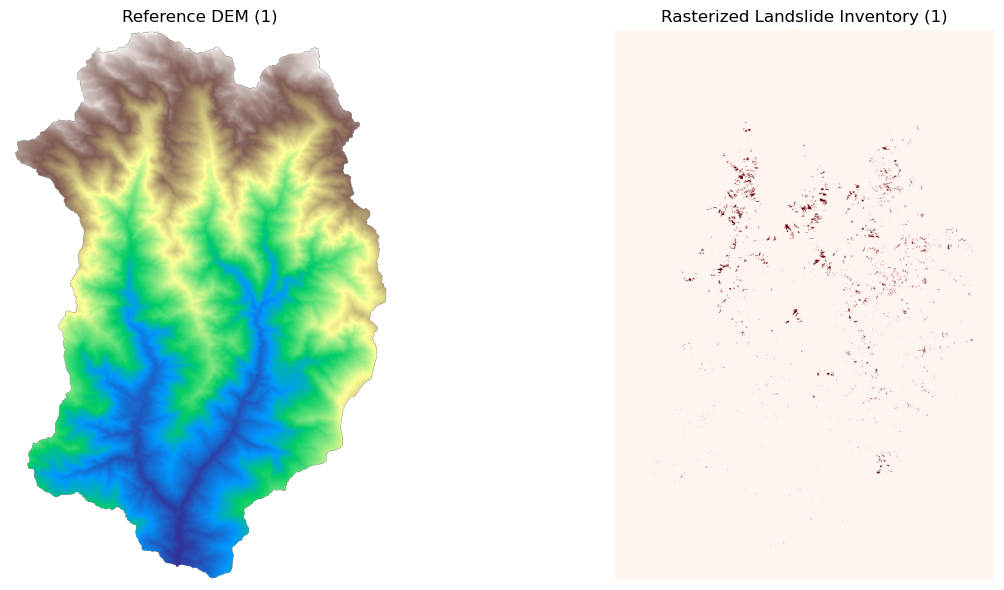

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

with rasterio.open(reference_raster) as src:
    dem = src.read(1, masked=True)

axes[0].imshow(dem, cmap="terrain")
axes[0].set_title(f"Reference DEM ({point_id})")
axes[0].set_axis_off()

axes[1].imshow(landslide_mask, cmap="Reds")
axes[1].set_title(f"Rasterized Landslide Inventory ({point_id})")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## Notes

- This notebook supports both:
  - automatic USGS inventory download
  - user-supplied inventory paths
- The inventory source should be declared in Step 1 config
- Optional thematic factors such as geology, roads, rainfall, or land cover can be added through `manual_thematic_factors`
- This notebook processes one selected watershed at a time using `point_id`